In [1]:
!pip install matplotlib==3.5.3 -q

!pip install phik -q

!pip install scikit-learn==1.6.1 -q

!pip install -U shap -q

In [2]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import phik
from phik import phik_matrix
from phik.report import plot_correlation_matrix

import warnings

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, LabelEncoder

from sklearn.impute import SimpleImputer 

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import roc_auc_score

import shap

RANDOM_STATE = 99

# Проект: Обучение с учителем: качество модели

Интернет-магазин «В один клик» продаёт товары: для детей, для дома, мелкую бытовую технику, косметику и даже продукты. Отчёт магазина за прошлый период показал, что активность покупателей начала снижаться. 

Задача - разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность.

Руководителем отдела сформирован план решения задачи.

1. Уровень финансовой активности постоянных покупателей промаркирован. В компании принято выделять два уровня активности: «снизилась», если клиент стал покупать меньше товаров, и «прежний уровень».

2 Собраны данные по клиентам:

- Признаки, которые описывают коммуникацию сотрудников компании с клиентом.
- Признаки, которые описывают продуктовое поведение покупателя. 
- Признаки, которые описывают покупательское поведение клиента. 
- Признаки, которые описывают поведение покупателя на сайте.

3. Требуется построить модель, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца.

4. В исследование нужно включить дополнительные данные финансового департамента о прибыльности клиента: какой доход каждый покупатель приносил компании за последние три месяца. Используя данные модели и данные о прибыльности клиентов, нужно выделить сегменты покупателей и разработать для них персонализированные предложения.

## Шаг 1. Загрузка данных

### market_file

In [3]:
market_file = pd.read_csv('/datasets/market_file.csv')
market_file.head()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


In [4]:
market_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

Таблица содержит данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении.

- id — номер покупателя в корпоративной базе данных.
- Покупательская активность — рассчитанный класс покупательской активности (целевой признак): «снизилась» или «прежний уровень».
- Тип сервиса — уровень сервиса, например «премиум» и «стандарт».
- Разрешить сообщать — информация о том, можно ли присылать покупателю дополнительные предложения о товаре. Согласие на это даёт покупатель.
- Маркет_актив_6_мес — среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев. Это значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента.
- Маркет_актив_тек_мес — количество маркетинговых коммуникаций в текущем месяце.
- Длительность — значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте.
- Акционные_покупки — среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев.
- Популярная_категория — самая популярная категория товаров у покупателя за последние 6 месяцев.
- Средний_просмотр_категорий_за_визит — показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца.
- Неоплаченные_продукты_штук_квартал — общее число неоплаченных товаров в корзине за последние 3 месяца.
- Ошибка_сервиса — число сбоев, которые коснулись покупателя во время посещения сайта.
- Страниц_за_визит — среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца.

**Пропуски в датафрейме отстутствуют, типы данных корректные.**

### market_money

In [5]:
market_money = pd.read_csv('/datasets/market_money.csv')
market_money.head()

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


In [6]:
market_money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


Таблица с данными о выручке, которую получает магазин с покупателя.

- id — номер покупателя в корпоративной базе данных.
- Период — название периода, во время которого зафиксирована выручка: 'текущий_месяц', 'предыдущий_месяц', 'препредыдущий_месяц'.
- Выручка — сумма выручки за период.

**Пропуски в датафрейме отстутствуют, типы данных корректные.**

### market_time

In [7]:
market_time = pd.read_csv('/datasets/market_time.csv')
market_time.head()

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


In [8]:
market_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


Таблица с данными о времени (в минутах), которое покупатель провёл на сайте в течение периода.

- id — номер покупателя в корпоративной базе данных.
- Период — название периода, во время которого зафиксировано общее время: 'текущий_месяц', 'предыдцщий_месяц'.
- минут — значение времени, проведённого на сайте, в минутах.

**Пропуски в датафрейме отстутствуют, типы данных корректные.**

### money

In [9]:
money = pd.read_csv('/datasets/money.csv', sep=';', decimal=',')
money.head()

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


In [10]:
money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


Таблица с данными о среднемесячной прибыли продавца за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю.

- id — номер покупателя в корпоративной базе данных.
- Прибыль — значение прибыли.

**Пропуски в датафрейме отстутствуют, типы данных корректные.**

## Шаг 2. Предобработка данных

### Названия столбцов
Для удобства работы с информацией в данном проекте названия столбцов оставим кириллическими.
Приведем написание названий к единому формату - уберем змеиное написание, где оно есть. Так читать названия на графиках и в таблицах будет комфортнее. С той же целью переименуем ряд столбцов.

In [11]:
market_file.columns = ['id', 'Покупательская активность', 'Тип сервиса', 'Разрешение на дополнительные предложения', \
                       'Маркетинговая активность за 6 месяцев', 'Маркетинговая активность за текущий месяц', \
                       'Длительность пользования сайтом в днях', 'Акционные покупки', 'Популярная категория', \
                       'Средний просмотр категорий за визит', 'Неоплаченные продукты штук квартал', 'Число сбоев', \
                       'Страниц за визит']

In [12]:
market_time.columns = ['id', 'Период', 'Время в минутах']

### Дубликаты

#### Явные дубликаты и столбец id

In [13]:
market_file.duplicated().sum()

0

In [14]:
market_file['id'].duplicated().sum()

0

In [15]:
market_file['id']

0       215348
1       215349
2       215350
3       215351
4       215352
         ...  
1295    216643
1296    216644
1297    216645
1298    216646
1299    216647
Name: id, Length: 1300, dtype: int64

**Таблица market_file содержит данные об 1300 разных id пользователей. Явные дубликаты отсутствуют.**

In [16]:
market_money.duplicated().sum()

0

In [17]:
market_money.nunique()

id         1300
Период        3
Выручка    2776
dtype: int64

In [18]:
market_money['id']

0       215348
1       215348
2       215348
3       215349
4       215349
         ...  
3895    216646
3896    216646
3897    216647
3898    216647
3899    216647
Name: id, Length: 3900, dtype: int64

**Таблица market_money содержит данные о выручке по тем же 1300 id за 3 месяца. Итого 3900 строк.**

In [19]:
market_time.duplicated().sum()

0

In [20]:
market_time.nunique()

id                 1300
Период                2
Время в минутах      20
dtype: int64

In [21]:
market_time['id']

0       215348
1       215348
2       215349
3       215349
4       215350
         ...  
2595    216645
2596    216646
2597    216646
2598    216647
2599    216647
Name: id, Length: 2600, dtype: int64

**Таблица market_time содержит данные о выручке по тем же 1300 id за 2 месяца. Итого 2600 строк.**

#### Проверка категориальных столбцов

**market_file**

In [22]:
market_file['Покупательская активность'].unique()

array(['Снизилась', 'Прежний уровень'], dtype=object)

In [23]:
market_file['Тип сервиса'].unique()

array(['премиум', 'стандартт', 'стандарт'], dtype=object)

In [24]:
market_file['Разрешение на дополнительные предложения'].unique()

array(['да', 'нет'], dtype=object)

In [25]:
market_file['Популярная категория'].unique()

array(['Товары для детей', 'Домашний текстиль', 'Косметика и аксесуары',
       'Техника для красоты и здоровья', 'Кухонная посуда',
       'Мелкая бытовая техника и электроника'], dtype=object)

**Среди категориальных столбцов таблицы market_file обнаружены неявные дубликаты в столбце 'Тип сервиса'. Устраним их.**

In [26]:
market_file['Тип сервиса'] = market_file['Тип сервиса'].replace('стандартт', 'стандарт')
market_file['Тип сервиса'].unique()

array(['премиум', 'стандарт'], dtype=object)

**market_money**

In [27]:
market_money['Период'].unique()

array(['препредыдущий_месяц', 'текущий_месяц', 'предыдущий_месяц'],
      dtype=object)

**market_time**

In [28]:
market_time['Период'].unique()

array(['текущий_месяц', 'предыдцщий_месяц'], dtype=object)

**Устраним опечатку.**

In [29]:
market_time['Период'] = market_time['Период'].replace('предыдцщий_месяц', 'предыдущий_месяц')
market_time['Период'].unique()

array(['текущий_месяц', 'предыдущий_месяц'], dtype=object)

#### Неявные дубликаты
Теоретически возможно наличие под разными id одного и того же пользователя (например, в связи с техничсекой ошибкой в данных). Тогда совпадут данные строк по всем столбцам, кроме id, в том числе по столбцам с боьшим количеством уникальных значений, таким как 'Длительность', 'Акционные покупки'.

Проверим наличие таких дубликатов.

In [30]:
market_file.drop('id', axis=1).duplicated().sum()

11

Повторяющихся сторк 11, что составляет 0.8% от общего количества. Уверенности в том, что это дубликаты, у нас нет. Если это дубликаты, столь маленькая доля не окажет существенного негативного влияния на иследование и моделирование. Поэтому сохраним данные.

## Шаг 3. Исследовательский анализ данных

### Выручка
Сумма выручки от пользователя помесячно за 3 периода: 'текущий_месяц', 'предыдущий_месяц', 'препредыдущий_месяц'. 

In [31]:
market_money['Выручка'].describe()

count      3900.000000
mean       5025.696051
std        1777.704104
min           0.000000
25%        4590.150000
50%        4957.500000
75%        5363.000000
max      106862.200000
Name: Выручка, dtype: float64

<AxesSubplot:>

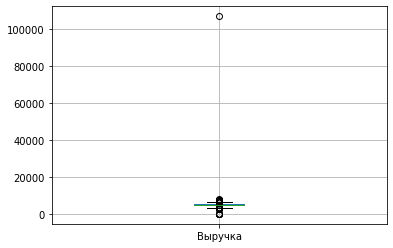

In [32]:
market_money.boxplot('Выручка')

Рассмотрм подробнее выдающееся значение.

In [33]:
market_money['Выручка'].sort_values(ascending=False).head(3)

98     106862.2
435      7799.4
262      7605.3
Name: Выручка, dtype: float64

In [34]:
market_money.loc[98]

id                215380
Период     текущий_месяц
Выручка         106862.2
Name: 98, dtype: object

In [35]:
market_money.query('id == 215380')

,id,Период,Выручка
96,215380,препредыдущий_месяц,5051.0
97,215380,предыдущий_месяц,6077.0
98,215380,текущий_месяц,106862.2


In [36]:
market_file.query('id == 215380')

,id,Покупательская активность,Тип сервиса,Разрешение на дополнительные предложения,Маркетинговая активность за 6 месяцев,Маркетинговая активность за текущий месяц,Длительность пользования сайтом в днях,Акционные покупки,Популярная категория,Средний просмотр категорий за визит,Неоплаченные продукты штук квартал,Число сбоев,Страниц за визит
32,215380,Снизилась,премиум,нет,1.7,4,637,0.94,Техника для красоты и здоровья,3,2,4,7


Под id 215380 пользователь уровня 'премиум' с популярной категорией 'Техника для красоты и здоровья'. Возможно, в текущем месяце он осуществил крупную покупку. При этом 'Покупательская активность' данного пользователя Снизилась.

**Выброс может негативно сказаться на обучении модели. Удалим данное значение, заменив его на средний чек пользователя по двум предыдущим месяцам.**

In [37]:
market_money.loc[98, 'Выручка'] = (5051+6077) /2
market_money.query('id == 215380')

,id,Период,Выручка
96,215380,препредыдущий_месяц,5051.0
97,215380,предыдущий_месяц,6077.0
98,215380,текущий_месяц,5564.0


In [38]:
market_money['Выручка'].describe()

count    3900.000000
mean     4999.722154
std       706.966984
min         0.000000
25%      4590.150000
50%      4957.500000
75%      5363.000000
max      7799.400000
Name: Выручка, dtype: float64

<AxesSubplot:>

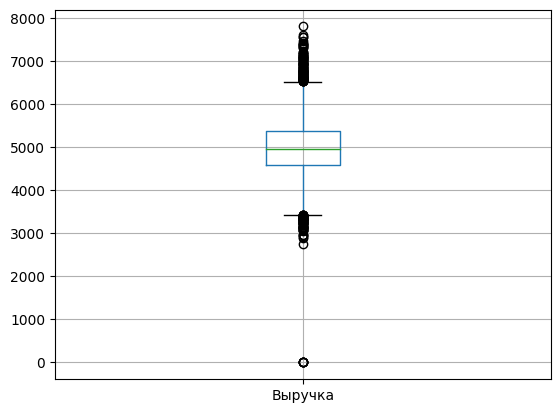

In [39]:
market_money.boxplot('Выручка')

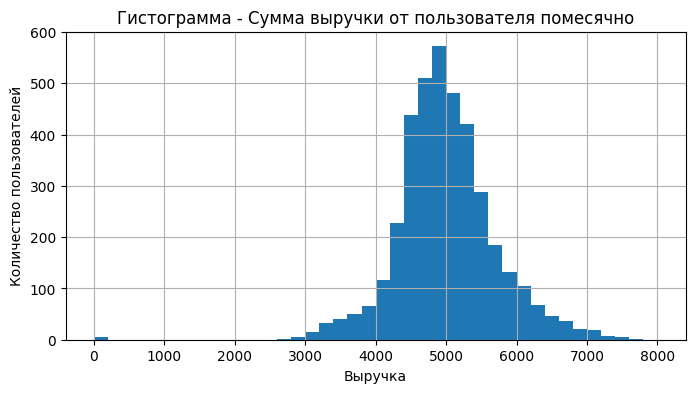

In [40]:
market_money['Выручка'].hist(bins=40, range=(0, 8000), figsize=(8, 4))
plt.title('Гистограмма - Сумма выручки от пользователя помесячно')
plt.xlabel('Выручка')
plt.ylabel('Количество пользователей')
plt.show()

In [41]:
market_money['Выручка'].sort_values().head(10)

0          0.0
2          0.0
34         0.0
35         0.0
28         0.0
29         0.0
356     2758.7
649     2890.0
662     2909.0
2485    2952.2
Name: Выручка, dtype: float64

Распределение значений выручки напоминает нормальное  с пиком в значении чуть менее 5 тыс. у.е. Половина всех строк датафрема содержать значения от 4,6 до 5,4 тыс. у.е.

При этом есть нулевые значения помесячной выручки. Минимальное положительное значение выручки 2,8 тыс. у.е.

**Для дальнейшего анализа и моделирования нам требуются пользователи с покупательской активностью не менее трёх месяцев**. **Посмотрим на пользователей, по которым есть данные о нулевой выручке. Для этого преобразуем датафрейм.**

In [42]:
market_money_pivot = market_money.pivot_table(index='id', columns='Период', values='Выручка').reset_index()
market_money_pivot.columns = ['id', 'предыдущий_месяц', 'препредыдущий_месяц', 'текущий_месяц']
market_money_pivot.query('текущий_месяц == 0 | предыдущий_месяц == 0 | препредыдущий_месяц == 0')

,id,предыдущий_месяц,препредыдущий_месяц,текущий_месяц
0,215348,0.0,0.0,3293.1
9,215357,0.0,0.0,5986.3
11,215359,0.0,0.0,4735.0


**Выборку попали 3 клиента с покупательской активностью только 1 месяц вместо 3. Удалим их из всех датафреймов.**

In [43]:
todrop = market_money_pivot.query('текущий_месяц == 0 | предыдущий_месяц == 0 | препредыдущий_месяц == 0')['id'].tolist()
todrop

[215348, 215357, 215359]

In [44]:
market_file = market_file[~market_file['id'].isin(todrop)]
market_money = market_money[~market_money['id'].isin(todrop)]
market_money_pivot = market_money_pivot[~market_money_pivot['id'].isin(todrop)]
market_time = market_time[~market_time['id'].isin(todrop)]
money = money[~money['id'].isin(todrop)]

display(market_file.shape)
display(market_money.shape)
display(market_money_pivot.shape)
display(market_time.shape)
display(money.shape)

(1297, 13)

(3891, 3)

(1297, 4)

(2594, 3)

(1297, 2)

**Пользователи с активностью менее 3 месяцев удалены размерности датафреймов корректные.**

### Время, проведённое на сайте
Значение времени в минутах, проведённого пользователем на сайте помесячно в периоды: 'текущий_месяц', 'предыдущий_месяц'.

In [45]:
market_time['Время в минутах'].describe()

count    2594.000000
mean       13.340401
std         4.081999
min         4.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        23.000000
Name: Время в минутах, dtype: float64

<AxesSubplot:>

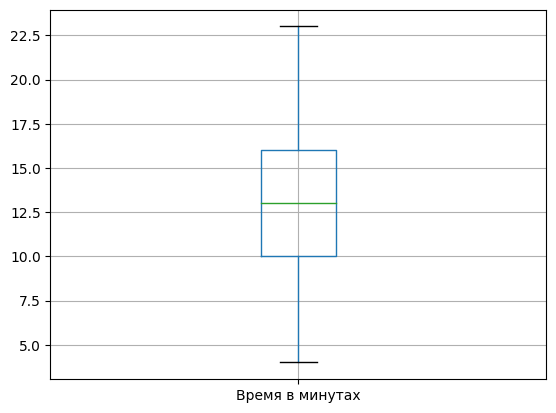

In [46]:
market_time.boxplot('Время в минутах')

Столбец 'Время в минутах' имеет тип int, заполнен дискретными значениями от 4 до 24. Построим Столбчатую диаграмму.

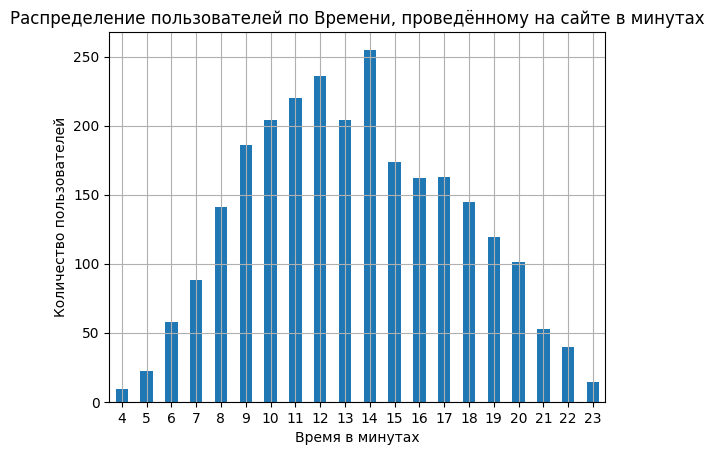

In [47]:
market_time.groupby('Время в минутах')['Время в минутах'].count().plot(kind='bar', grid=True)
plt.xticks(rotation=0)
plt.title('Распределение пользователей по Времени, проведённому на сайте в минутах')
plt.xlabel('Время в минутах')
plt.ylabel('Количество пользователей')
plt.show()

Среднемесячное время, проводимое пользователем на сайте - 13 минут. Распределение напрминает форму колокола, при этом имеет два пика: 12 и 14 минут.

**Преобразуем таблицу со временем, проведенным на сайте, в сводную, аналогично таблице с выручкой.** Это пригодится при объединении датафреймов.

In [48]:
market_time_pivot = market_time.pivot_table(index='id', columns='Период', values='Время в минутах').reset_index()
market_time_pivot.columns = ['id', 'предыдущий_месяц', 'текущий_месяц']
market_time_pivot.head(3)

,id,предыдущий_месяц,текущий_месяц
0,215349,12,10
1,215350,8,13
2,215351,11,13


### Покупательская активность
Целевой параметр

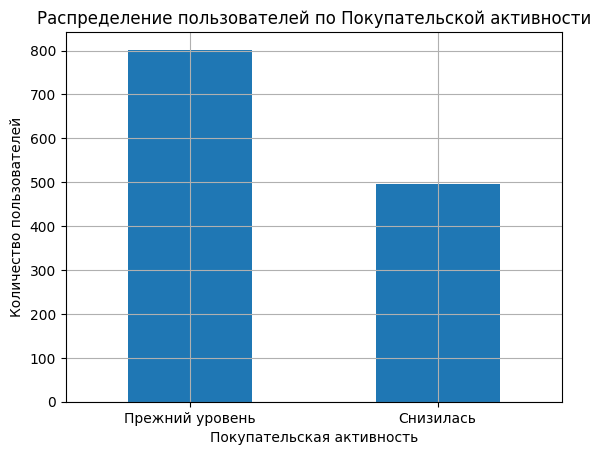

In [49]:
market_file['Покупательская активность'].value_counts().plot(kind='bar', grid=True)
plt.xticks(rotation=0)
plt.title('Распределение пользователей по Покупательской активности')
plt.xlabel('Покупательская активность')
plt.ylabel('Количество пользователей')
plt.show()

Соотношение значений целевого признака не равное. При моделировании необходимо будет это учесть.

### Тип сервиса

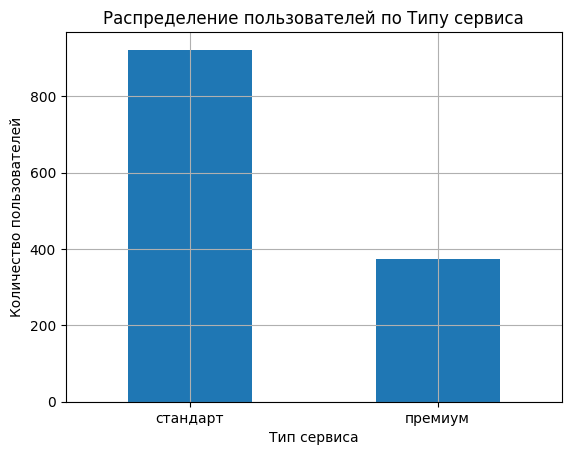

In [50]:
market_file['Тип сервиса'].value_counts().plot(kind='bar', grid=True)
plt.xticks(rotation=0)
plt.title('Распределение пользователей по Типу сервиса')
plt.xlabel('Тип сервиса')
plt.ylabel('Количество пользователей')
plt.show()

Большинство покупателей пользуются сервисом уровня стандарт.

### Разрешение на дополнительные предложения
Информация о том, можно ли присылать покупателю дополнительные предложения о товаре. Согласие на это даёт покупатель.

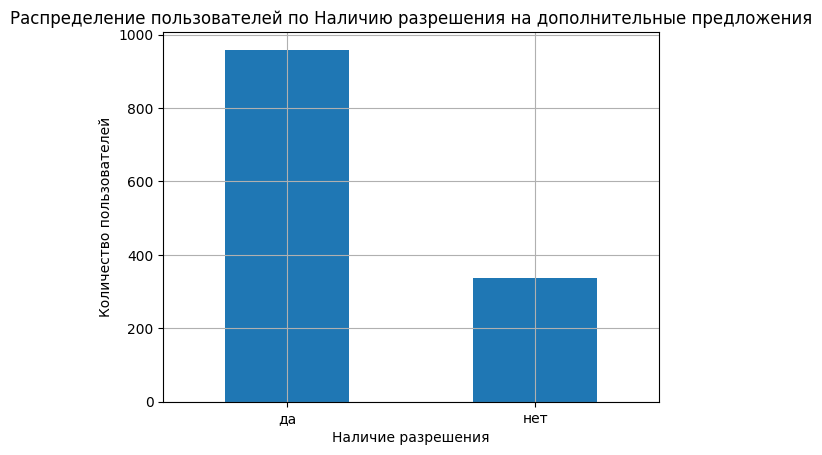

In [51]:
market_file['Разрешение на дополнительные предложения'].value_counts().plot(kind='bar', grid=True)
plt.xticks(rotation=0)
plt.title('Распределение пользователей по Наличию разрешения на дополнительные предложения')
plt.xlabel('Наличие разрешения')
plt.ylabel('Количество пользователей')
plt.show()

Большинство покупателей разрешили присылать им пополнительную информацию о товарах.

### Популярная категория

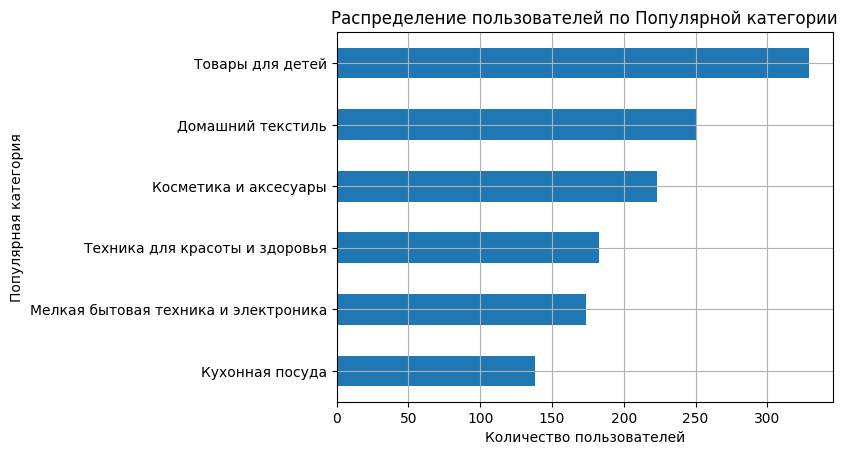

In [52]:
market_file['Популярная категория'].value_counts().sort_values().plot(kind='barh', grid=True)
plt.title('Распределение пользователей по Популярной категории')
plt.xlabel('Количество пользователей')
plt.ylabel('Популярная категория')
plt.show()

Товары для детей наиболее часто становятся популярной категорией для пользователей. Кухонной посудой интересуются реже, чем другими категорями.

### Маркетинговая активность за 6 месяцев
Cреднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев. Это значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента.

In [53]:
market_file['Маркетинговая активность за 6 месяцев'].describe()

count    1297.000000
mean        4.254433
std         1.015618
min         0.900000
25%         3.700000
50%         4.200000
75%         4.900000
max         6.600000
Name: Маркетинговая активность за 6 месяцев, dtype: float64

<AxesSubplot:>

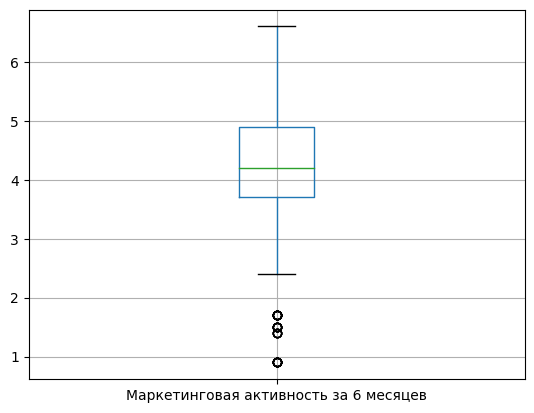

In [54]:
market_file.boxplot('Маркетинговая активность за 6 месяцев')

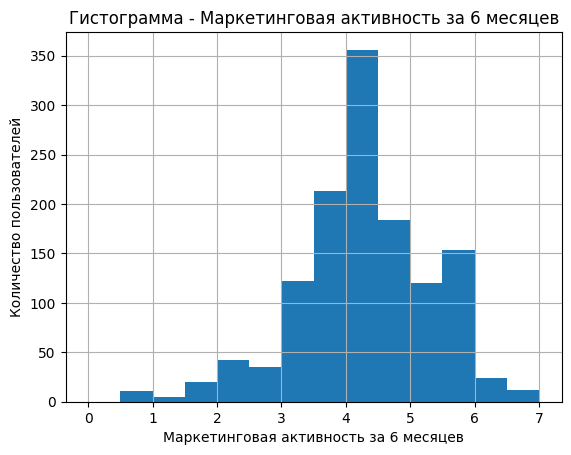

In [55]:
market_file['Маркетинговая активность за 6 месяцев'].hist(bins=14, range=(0, 7))
plt.title('Гистограмма - Маркетинговая активность за 6 месяцев')
plt.xlabel('Маркетинговая активность за 6 месяцев')
plt.ylabel('Количество пользователей')
plt.show()

Распределение значений по столбцу 'Маркетинговая активность за 6 месяцев' по форме напоминает колокол.  Среднее и медианное значение среднемесячного количества маркетинговых коммуникаций на покупателя - 4.2. Есть небольшое количество покупателей с очень маленьким количеством маркетинговых коммуникаций (около 1 в месяц), такое возможно, выбросами эти значениния не признаем.

### Маркетинговая активность за текущий месяц
Количество маркетинговых коммуникаций в текущем месяце.

In [56]:
market_file['Маркетинговая активность за текущий месяц'].describe()

count    1297.000000
mean        4.009252
std         0.696048
min         3.000000
25%         4.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: Маркетинговая активность за текущий месяц, dtype: float64

Столбец 'Маркетинговая активность за текущий месяц' имеет тип int, заполнен дискретными значениями 3, 4, 5. Построим Столбчатую диаграмму.

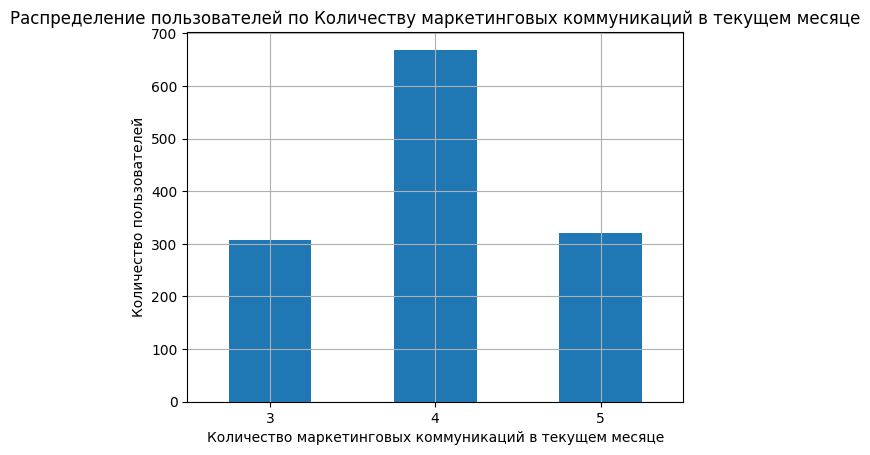

In [57]:
market_file.groupby('Маркетинговая активность за текущий месяц')['Маркетинговая активность за текущий месяц'].count()\
.plot(kind='bar', grid=True)
plt.xticks(rotation=0)
plt.title('Распределение пользователей по Количеству маркетинговых коммуникаций в текущем месяце')
plt.xlabel('Количество маркетинговых коммуникаций в текущем месяце')
plt.ylabel('Количество пользователей')
plt.show()

На чуть более половины пользователей пришлось по 4 маркетинговые коммуникации в текущем месяце. При мерно по 1/4 пользователей получили 3 или 5 коммуникаций.

Признак может быть отнесен к категориальным при моделировании. Этот вопрос требует дополнительной проработки, так как в тестовой выборке в другие периоды могут появляться другие значения в большом количестве (исходя из диапозона среднемесячных значений маркетинговых коммуникаций за 6 месяцев от 0.9 до 6.6).

### Длительность пользования сайтом в днях
Количество дней с момента регистрации покупателя на сайте.

In [58]:
market_file['Длительность пользования сайтом в днях'].describe()

count    1297.000000
mean      602.993832
std       249.101456
min       121.000000
25%       410.000000
50%       607.000000
75%       806.000000
max      1079.000000
Name: Длительность пользования сайтом в днях, dtype: float64

<AxesSubplot:>

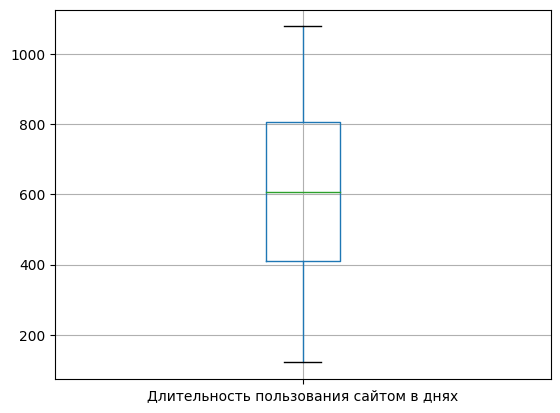

In [59]:
market_file.boxplot('Длительность пользования сайтом в днях')

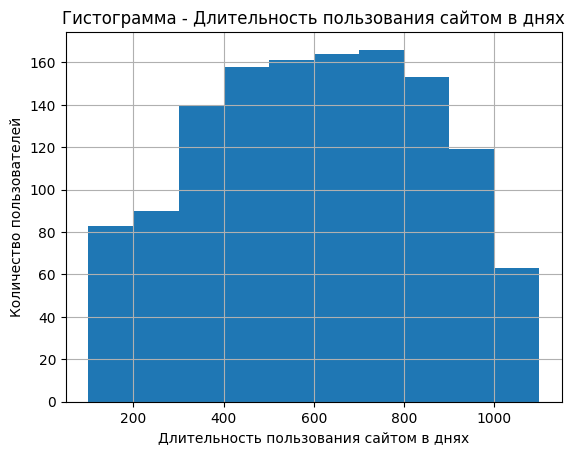

In [60]:
market_file['Длительность пользования сайтом в днях'].hist(bins=10, range=(100, 1100))
plt.title('Гистограмма - Длительность пользования сайтом в днях')
plt.xlabel('Длительность пользования сайтом в днях')
plt.ylabel('Количество пользователей')
plt.show()

Распределение пользователей в выборке по количеству дней с момента регистрации на сайте по форме напоминает колокол без ярко выраженной вершины.

Минимальный "стаж" пользователя в выборке 121 день - чуть менее 4 месяцев (что требуется для расчета ряда показателей за 3 месяца). Макимальный "стаж" пользователя в выборке 1079 дней - чуть менее 3 лет. Медиана и среднее примерно совпадают - 1,6 года. Выбросов нет.

### Акционные покупки
Cреднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев.

In [61]:
market_file['Акционные покупки'].describe()

count    1297.000000
mean        0.320547
std         0.249657
min         0.110000
25%         0.170000
50%         0.240000
75%         0.300000
max         0.990000
Name: Акционные покупки, dtype: float64

<AxesSubplot:>

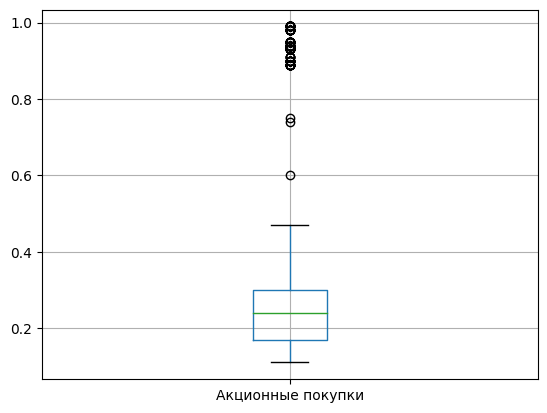

In [62]:
market_file.boxplot('Акционные покупки')

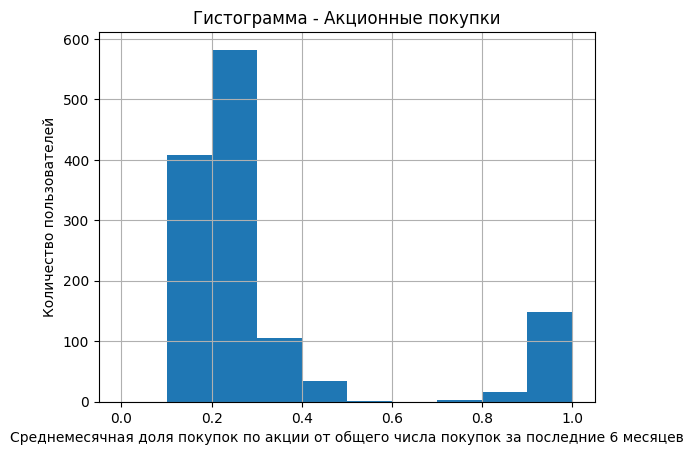

In [63]:
market_file['Акционные покупки'].hist(bins=10, range=(0, 1))
plt.title('Гистограмма - Акционные покупки')
plt.xlabel('Cреднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев')
plt.ylabel('Количество пользователей')
plt.show()

In [64]:
market_file[market_file['Акционные покупки'] > 0.45]['Акционные покупки'].sort_values().head()

665    0.47
417    0.60
14     0.74
1      0.75
302    0.89
Name: Акционные покупки, dtype: float64

У 50% пользователей доля акционных покупок составляет от 17% до 30%. При этом на боксплоте мы видим скопление высоких значений, на гистограмме второй пик интервале от 0.9 до 1.0. Интервал от 0.47 до 0.74 почти пуст - содержит только один объект 0.6.

Для моделирования данный признак можно перевести в категориальный: пользователи с умеренной долей акционных покупок и пользователи, которые покупают преимущественно по акциям. В качестве границы категорий может выступить значение 0.7. Создадим такой признак.

In [65]:
def categorize_promo_share (promo_share):
    try:
        if promo_share < 0.70:
            return 'умеренная'
        if promo_share >= 0.70:
            return 'высокая'
    except:
        return Nan
    
market_file['Доля покупок по акции категориальный'] = market_file['Акционные покупки'].agg(categorize_promo_share)

market_file[['Акционные покупки', 'Доля покупок по акции категориальный']].head(3)

,Акционные покупки,Доля покупок по акции категориальный
1,0.75,высокая
2,0.14,умеренная
3,0.99,высокая


In [66]:
market_file[['Акционные покупки', 'Доля покупок по акции категориальный']].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1297 entries, 1 to 1299
Data columns (total 2 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Акционные покупки                     1297 non-null   float64
 1   Доля покупок по акции категориальный  1297 non-null   object 
dtypes: float64(1), object(1)
memory usage: 30.4+ KB


### Средний просмотр категорий за визит
Среднее количество категорий, которое покупатель просматривал за визит в течение последнего месяца.

In [67]:
market_file['Средний просмотр категорий за визит'].describe()

count    1297.000000
mean        3.267540
std         1.354623
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         6.000000
Name: Средний просмотр категорий за визит, dtype: float64

Столбец 'Средний просмотр категорий за визит' имеет тип int, заполнен дискретными значениями от 1 до 6. Построим Столбчатую диаграмму.

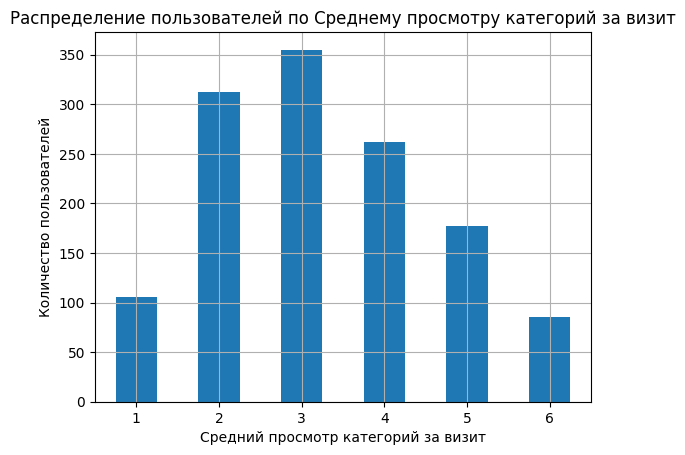

In [68]:
market_file.groupby('Средний просмотр категорий за визит')['Средний просмотр категорий за визит'].count()\
.plot(kind='bar', grid=True)
plt.xticks(rotation=0)
plt.title('Распределение пользователей по Среднему просмотру категорий за визит')
plt.xlabel('Средний просмотр категорий за визит')
plt.ylabel('Количество пользователей')
plt.show()

Столбчатая диграмма по форме напоминает колокол с пиком в значении 3, оно же является медианой и средним.

### Страниц за визит
Среднее количество страниц, которое просмотривал покупатель за один визит на сайт за последние 3 месяца.

In [69]:
market_file['Страниц за визит'].describe()

count    1297.000000
mean        8.186584
std         3.977061
min         1.000000
25%         5.000000
50%         8.000000
75%        11.000000
max        20.000000
Name: Страниц за визит, dtype: float64

<AxesSubplot:>

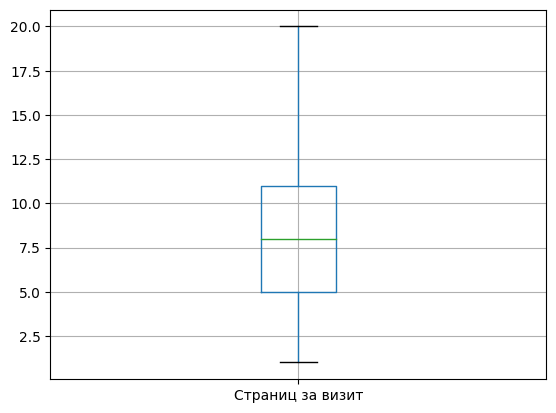

In [70]:
market_file.boxplot('Страниц за визит')

Столбец 'Страниц за визит' имеет тип int, заполнен дискретными значениями от 1 до 20. Построим Столбчатую диаграмму.

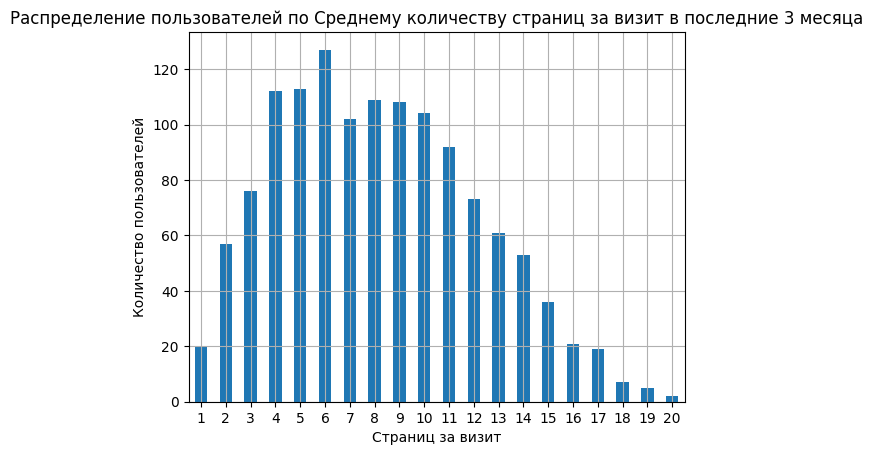

In [71]:
market_file.groupby('Страниц за визит')['Страниц за визит'].count()\
.plot(kind='bar', grid=True)
plt.xticks(rotation=0)
plt.title('Распределение пользователей по Среднему количеству страниц за визит в последние 3 месяца')
plt.xlabel('Страниц за визит')
plt.ylabel('Количество пользователей')
plt.show()

Распределение по форме напоминает скошенный вправо колокол.

Пик в значении 6, второй пик в значении 8. Возможно, пользователям, просмотривающим 7 страницу, направляется ссылка на некое предложение, на которое многие откликаются. Поэтому просмтотров 7 страниц меньше, чем 8, 9, и 10.

### Неоплаченные продукты штук квартал
Общее число неоплаченных товаров в корзине за последние 3 месяца.

In [72]:
market_file['Неоплаченные продукты штук квартал'].describe()

count    1297.000000
mean        2.841172
std         1.973451
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: Неоплаченные продукты штук квартал, dtype: float64

<AxesSubplot:>

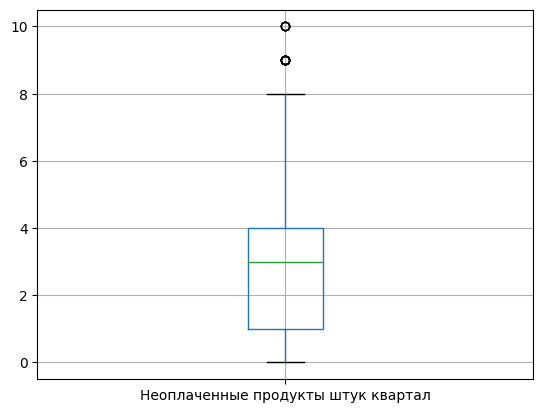

In [73]:
market_file.boxplot('Неоплаченные продукты штук квартал')

Столбец 'Неоплаченные продукты штук квартал' имеет тип int, заполнен дискретными значениями от 1 до 10. Построим Столбчатую диаграмму.

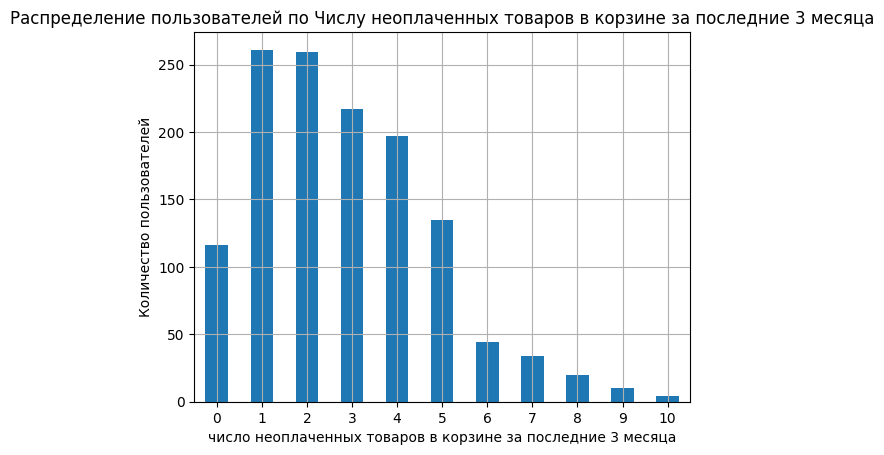

In [74]:
market_file.groupby('Неоплаченные продукты штук квартал')['Неоплаченные продукты штук квартал'].count()\
.plot(kind='bar', grid=True)
plt.xticks(rotation=0)
plt.title('Распределение пользователей по Числу неоплаченных товаров в корзине за последние 3 месяца')
plt.xlabel('число неоплаченных товаров в корзине за последние 3 месяца')
plt.ylabel('Количество пользователей')
plt.show()

Большинство пользователей держат в корзине неоплаченными от 1 до 4 товаров. Распределение скошено вправо.

### Число сбоев
Число сбоев, которые коснулись покупателя во время посещения сайта.

In [75]:
market_file['Число сбоев'].describe()

count    1297.000000
mean        4.184271
std         1.950973
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max         9.000000
Name: Число сбоев, dtype: float64

<AxesSubplot:>

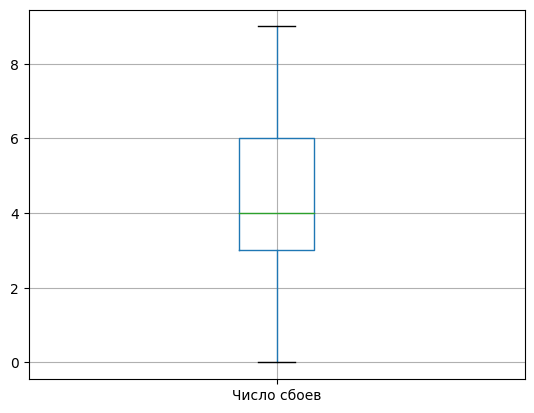

In [76]:
market_file.boxplot('Число сбоев')

Столбец 'Число сбоев' имеет тип int, заполнен дискретными значениями от 1 до 9. Построим Столбчатую диаграмму.

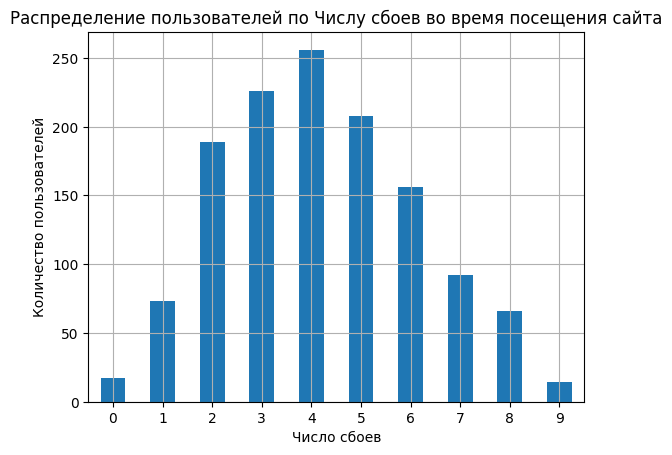

In [77]:
market_file.groupby('Число сбоев')['Число сбоев'].count()\
.plot(kind='bar', grid=True)
plt.xticks(rotation=0)
plt.title('Распределение пользователей по Числу сбоев во время посещения сайта')
plt.xlabel('Число сбоев')
plt.ylabel('Количество пользователей')
plt.show()

Распределение числа сбоев имеет форму колокола в диапозоне от 0 до 9 с пиком в значении 4.

### Прибыль
Среднемесячная прибыль продавца за последние 3 месяца от продаж каждому покупателю.

In [78]:
money['Прибыль'].describe()

count    1297.000000
mean        3.997610
std         1.010813
min         0.860000
25%         3.300000
50%         4.040000
75%         4.670000
max         7.430000
Name: Прибыль, dtype: float64

<AxesSubplot:>

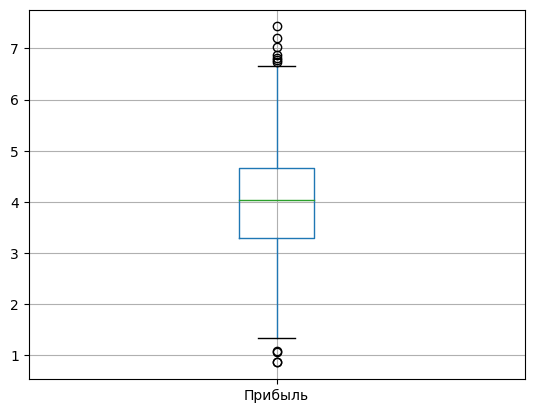

In [79]:
money.boxplot('Прибыль')

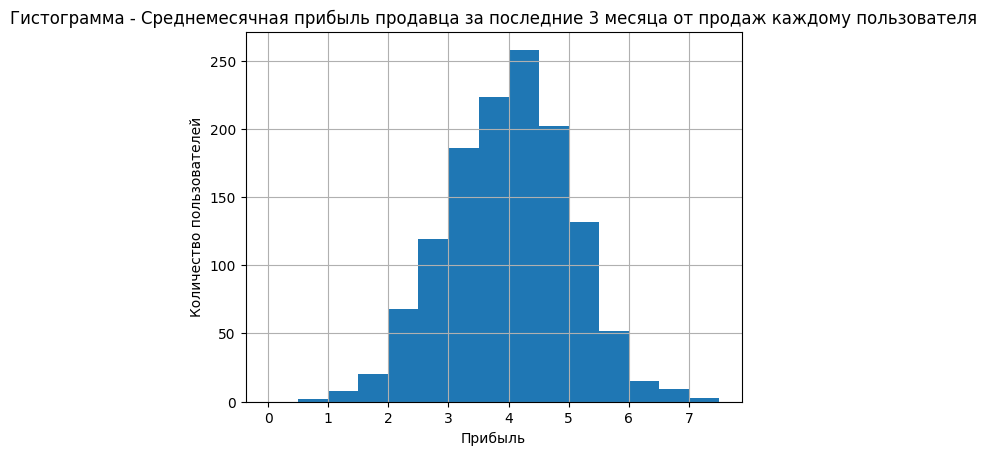

In [80]:
money['Прибыль'].hist(bins=15, range=(0, 7.5))
plt.title('Гистограмма - Среднемесячная прибыль продавца за последние 3 месяца от продаж каждому пользователя')
plt.xlabel('Прибыль')
plt.ylabel('Количество пользователей')
plt.show()

Распределение значений среднемесячной прибыли от продаж каждому покупателю имеет форму колокола в диапозоне от 0.8 до 7.5 у.е. Среднее значение и медиана составляют 4 у.е. Половина всех пользователей дают среднемесячную прибыль от 3.3 до 4.67 у.е.

### Вывод
- Для выполнения рабты отбраны 1297 пользователей с покупательской активностью не менее трёх месяцев (таких, которые что-либо покупали в этот период).
- Одно аномальное значение выручки в текущем месяце заменено на средний чек пользователя по двум предыдущим месяцам.
- Целевой параметр 'Покупательская активность' делит пользователей на две неравные группы, что необходимо будет учесть при моделировании.
- Другие категориальные параметры *('Тип сервиса', 'Разрешение на дополнительные предложения', 'Популярная категория')* также делят пользователей на неравные, но существенные по численности группы.
- Количественные параметры *'Маркетинговая активность за 6 месяцев', 'Маркетинговая активность за текущий месяц', 'Длительность пользования сайтом в днях', 'Средний просмотр категорий за визит', 'Неоплаченные продукты штук квартал', 'Число сбоев', 'Страниц за визит', 'Выручка, 'Время в минутах', 'Прибыль'* имеют распределение по форме близкое к нормальному.
- Распределение количественного параметра *'Акционные покупки'* говорит о том, что есть две группы:  пользователи с умеренной долей акционных покупок и пользователи, которые покупают преимущественно по акциям. Создана категоряальная версия данного параметра. 
- Признак *'Маркетинговая активность за текущий месяц'* также может быть отнесен к категориальным при моделировании, так как имеет всего 3 дискретных значения (3, 4, 5). Этот вопрос требует дополнительной проработки, так как в тестовой выборке в другие периоды могут появляться другие значения в большом количестве (исходя из диапозона среднемесячных значений маркетинговых коммуникаций за 6 месяцев от 0.9 до 6.6).

## Шаг 4. Объединение таблиц
Объединим таблицы market_file, market_money_pivot, market_time_pivot.

In [81]:
data = (market_file.merge(market_money_pivot, on='id')
        .merge(market_time_pivot, on='id', suffixes=('', '_время')))
data = data.rename(columns={'предыдущий_месяц': 'Выручка за предыдущий месяц', \
                        'препредыдущий_месяц': 'Выручка за препредыдущий месяц', \
                        'текущий_месяц': 'Выручка за текущий месяц', \
                        'предыдущий_месяц_время': 'Время в минутах за предыдущий месяц', \
                        'текущий_месяц_время': 'Время в минутах за текущий месяц'})
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1297 entries, 0 to 1296
Data columns (total 19 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id                                         1297 non-null   int64  
 1   Покупательская активность                  1297 non-null   object 
 2   Тип сервиса                                1297 non-null   object 
 3   Разрешение на дополнительные предложения   1297 non-null   object 
 4   Маркетинговая активность за 6 месяцев      1297 non-null   float64
 5   Маркетинговая активность за текущий месяц  1297 non-null   int64  
 6   Длительность пользования сайтом в днях     1297 non-null   int64  
 7   Акционные покупки                          1297 non-null   float64
 8   Популярная категория                       1297 non-null   object 
 9   Средний просмотр категорий за визит        1297 non-null   int64  
 10  Неоплаченные продукты шт

**Данные объединены.**

## Шаг 5. Корреляционный анализ
Построим матрицу коэффициентов корреляции Фи.

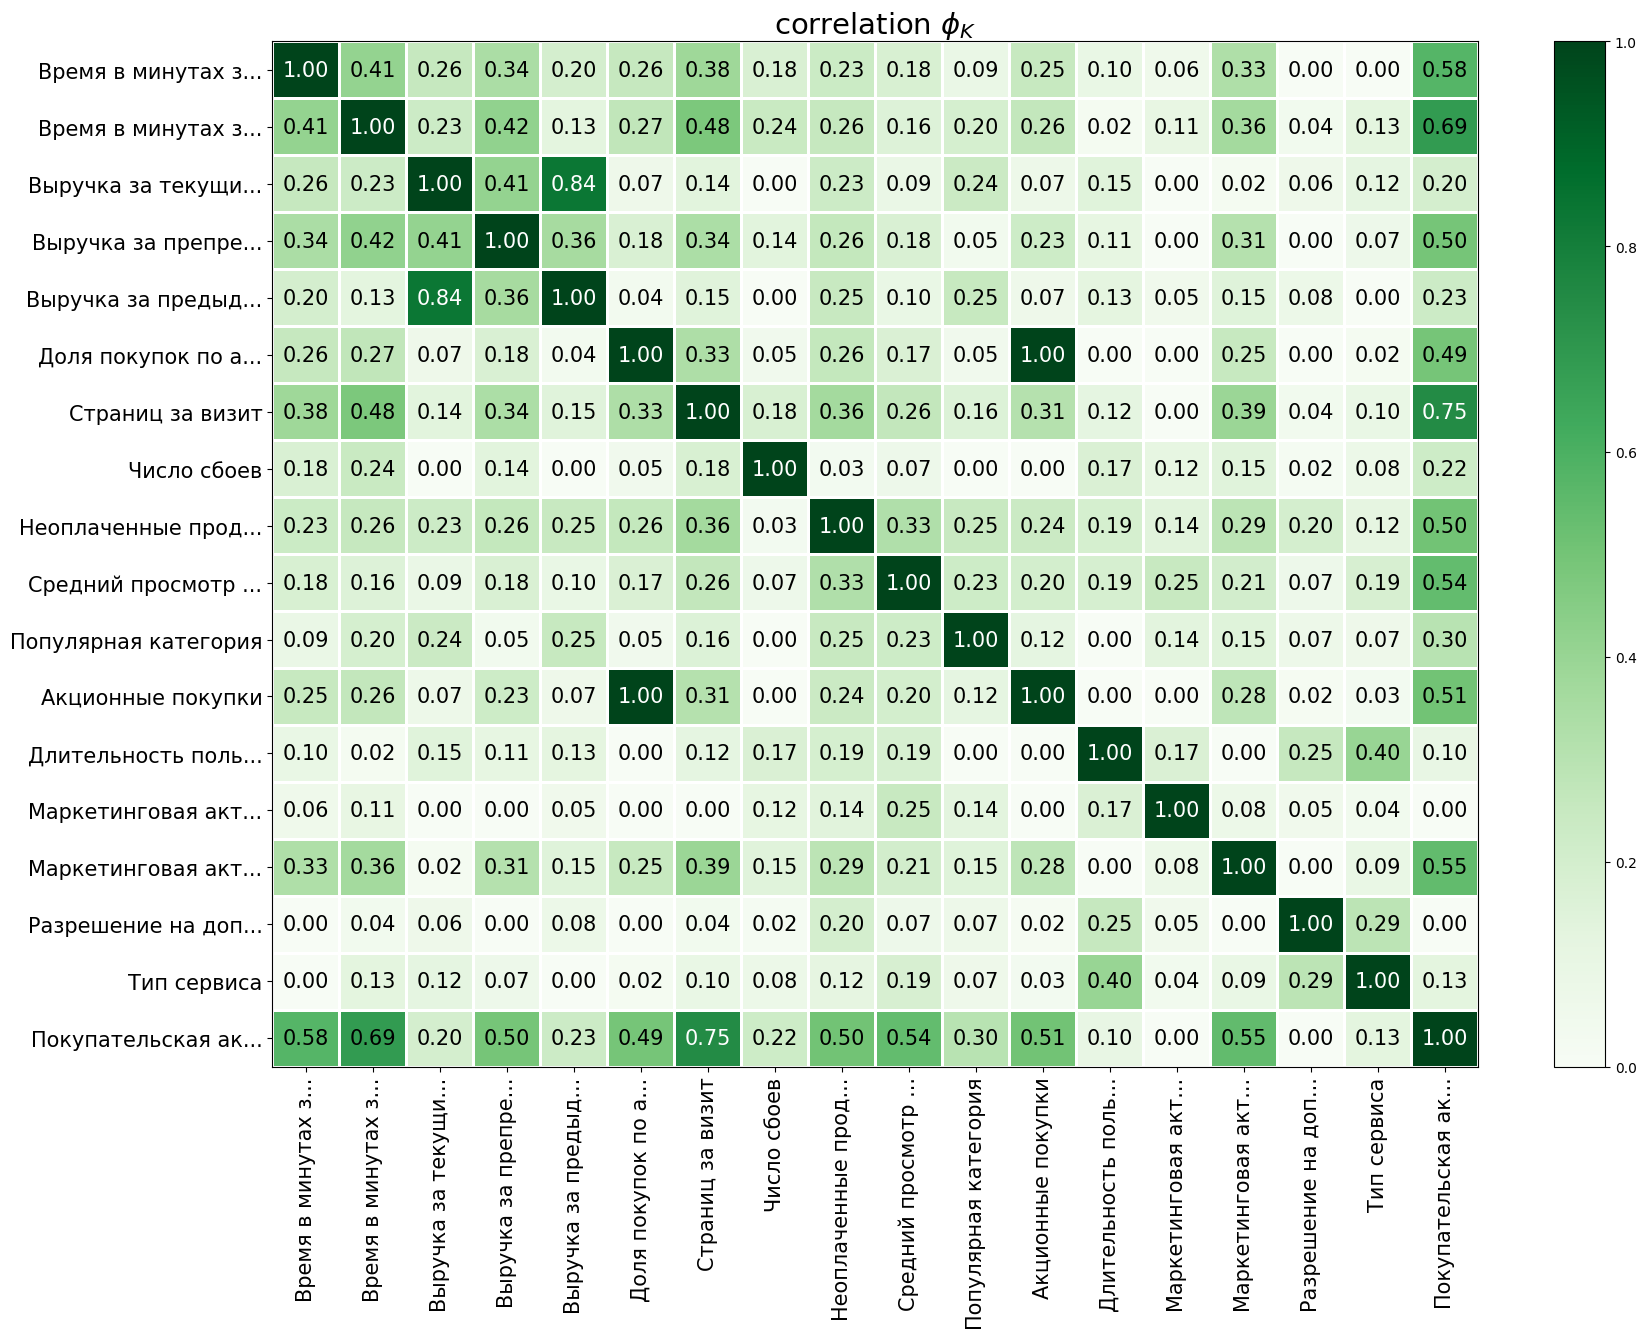

In [82]:
interval_cols = ['Маркетинговая активность за 6 месяцев', 'Маркетинговая активность за текущий месяц', \
                 'Длительность пользования сайтом в днях', 'Акционные покупки', 'Средний просмотр категорий за визит', \
                 'Неоплаченные продукты штук квартал', 'Число сбоев', 'Страниц за визит', 
                 'Выручка за предыдущий месяц', 'Выручка за препредыдущий месяц', 'Выручка за текущий месяц', \
                 'Время в минутах за предыдущий месяц', 'Время в минутах за текущий месяц',]

phik_overview = phik_matrix(data.drop('id', axis=1), interval_cols=interval_cols) 

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(18, 13.5)
) 

Ожидаемо, наблюдаем мультиколлинеарность между признаками 'Акционные покупки' и его категориальным аналогом 'Доля покупок по акции'. **Корреляция с целевым параметром немного выше у исходного количественного признака 'Акционные покупки', поэтому для моделирования будем использовать его.**

## Шаг 6. Использование пайплайнов

### Подготовка выборок
Создадим датафреймы Х и y.

In [83]:
X = data.drop(['id', 'Покупательская активность', 'Доля покупок по акции категориальный'], axis=1)
y = data['Покупательская активность']

Разделим датафреймы на выборки.

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = RANDOM_STATE, stratify = y)

Целевой параметр y кодируем LabelEncoder.

In [85]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

LabelEncoder сортирует классы в лексикографическом порядке.

**Значение 'Прежний уровень' закодировалась как 0, 'Снизилась' — как 1.**

### Пайплайн
Списки признаков для кодирования и масштабирования:

In [86]:
ohe_columns = ['Разрешение на дополнительные предложения', 'Популярная категория']
ord_columns = ['Тип сервиса']
num_columns = ['Маркетинговая активность за 6 месяцев', 'Маркетинговая активность за текущий месяц',
               'Длительность пользования сайтом в днях', 'Акционные покупки', 'Средний просмотр категорий за визит', \
               'Неоплаченные продукты штук квартал', 'Число сбоев', 'Страниц за визит', \
               'Выручка за предыдущий месяц', 'Выручка за препредыдущий месяц', 'Выручка за текущий месяц', \
               'Время в минутах за предыдущий месяц', 'Время в минутах за текущий месяц']

**Кодирование:**

In [87]:
ohe_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ohe', 
            OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
        )
    ]
) 

In [88]:
ord_pipe = Pipeline(
    [
        (
            'simpleImputer_before_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',  
            OrdinalEncoder(
                categories=[
                    ['стандарт', 'премиум']
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
        (
            'simpleImputer_after_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
) 

**Собираем пайплайн:**

In [89]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
) 

In [90]:
pipe_final = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
)

### Подбор модели и гиперпараметров

Обучим четыре модели: KNeighborsClassifier(), DecisionTreeClassifier(), LogisticRegression() и SVC(), подобрав для них гиперпараметры.

Для каждой модели подготовим данные с разным масштабированием: StandardScaler(), MinMaxScaler()

При подборе гиперпараметров будем использовать метрику ROC-AUC с учетом следующего:
- В выборке присутствует дисбаланс классов, ROC-AUC не чувствительна к дисбалансу.
- ROC-AUC учитывает все возможные пороги классификации одновременно, что дает комплексную оценку качеств модели.
- ROC-AUC позволяет сравнивать между собой несколько моделей классификации, что нам и требуется.

Для перебора вариантов моделей и гиперпараметров применим RandomizedSearchCV.

In [91]:
param_distributions = [

    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 11),
        'models__max_features': range(2, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 9),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },

    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'models__C': range(1, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    
    {
        'models': [SVC(probability=True, random_state=RANDOM_STATE)],
        'models__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    }
]

In [92]:
random_search = RandomizedSearchCV(
    pipe_final, 
    param_distributions=param_distributions, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

display('Лучшая модель:\n', random_search.best_estimator_)
display('Пареметры лучшей модели:\n', random_search.best_params_)
'ROC-AUC лучшей модели на тренировочной выборке:', random_search.best_score_

'Лучшая модель:\n'

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Разрешение на '
                                                   'дополнительные предложения',
                                                   'Популярная категория']),
                                                 ('ord',
                                                  Pipeline(steps=[('sim...
                                                   'Акционные покупки',
                                                   'Средний просмотр категорий '
                                                   'за визит',
                                                   'Неоплаченные продукты штук '
                                                   'квартал',
                                                   'Число сбоев',
                                                   'Страниц за визит',
                                                   'Выручка за предыдущий '
                                                   'месяц',
                                                   'Выручка за препредыдущий '
                                                   'месяц',
                                                   'Выручка за текущий месяц',
                                                   'Время в минутах за '
                                                   'предыдущий месяц',
                                                   'Время в минутах за текущий '
                                                   'месяц'])])),
                ('models',
                 LogisticRegression(C=3, penalty='l1', random_state=99,
                                    solver='liblinear'))])

'Пареметры лучшей модели:\n'

{'preprocessor__num': MinMaxScaler(),
 'models__C': 3,
 'models': LogisticRegression(penalty='l1', random_state=99, solver='liblinear')}

('ROC-AUC лучшей модели на тренировочной выборке:', 0.8959945126945128)

**Выбрана логистическая регрессия с параметром С = 3. Примененное масштабирование - MinMaxScaler().**

**Метрика ROC-AUC на тренировочной выборке 0.90.**

**Сделаем предсказание на тестовой выборке и рассчитаем метрику.**

In [93]:
probabilities_test = random_search.predict_proba(X_test)
f'ROC-AUC на тестовой выборке: {roc_auc_score(y_test, probabilities_test[:, 1])}'

'ROC-AUC на тестовой выборке: 0.9230861819932595'

**На тестовой выборке метрика ROC-AUC приняла значение 0.92, что говорит о хорошем качестве работы модели.**

## Шаг 7. Анализ важности признаков

Оцениим важность признаков для лучшей модели с помощью **метода SHAP**. 

Преобразуем X_test при помощи препроцессора лучшей модели:

In [94]:
X_test_p = pd.DataFrame(random_search.best_estimator_.named_steps['preprocessor'].transform(X_test), \
                        columns=random_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()) 

Рассчитаем shap_values:

In [95]:
explainer = shap.LinearExplainer(random_search.best_estimator_.named_steps['models'], X_test_p)
shap_values = explainer(X_test_p)

### shap.plots.bar
Построим диаграмму shap.plots.bar, отражающую средние модули SHAP-значений признаков по всем наблюдениям.

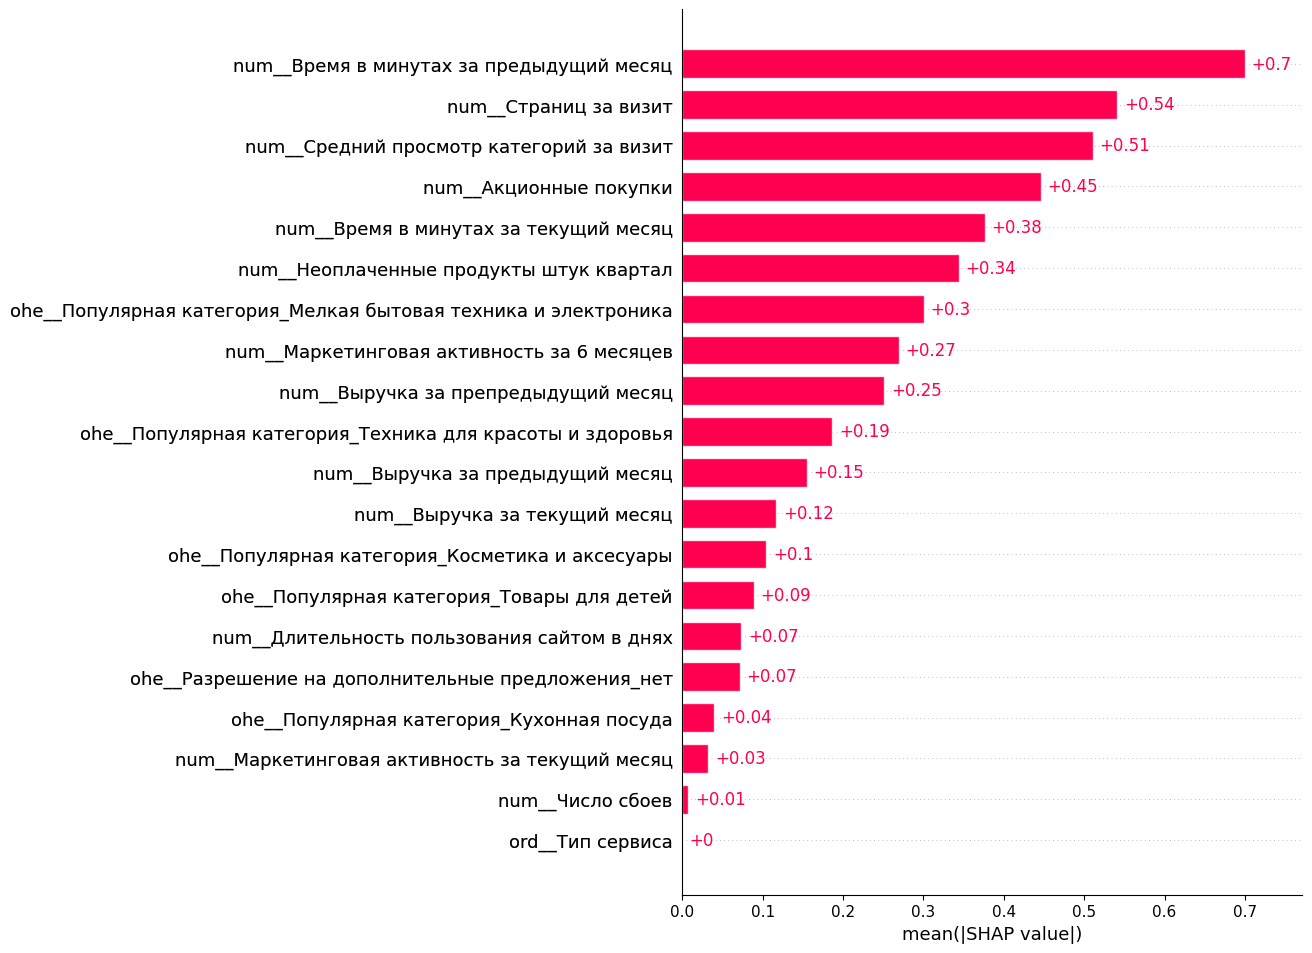

In [96]:
shap.plots.bar(shap_values, max_display=20)

**ТОП-3 признаков, влияющих на классификацию: 'Время (на сайте) в минутах за предудущий месяц', 'Страниц за визит', 'Средний просмотр категорий за визит'.**

### shap.plots.beeswarm
Визуализируем вклад признаков в каждое предсказание модели при помощи shap.plots.beeswarm.

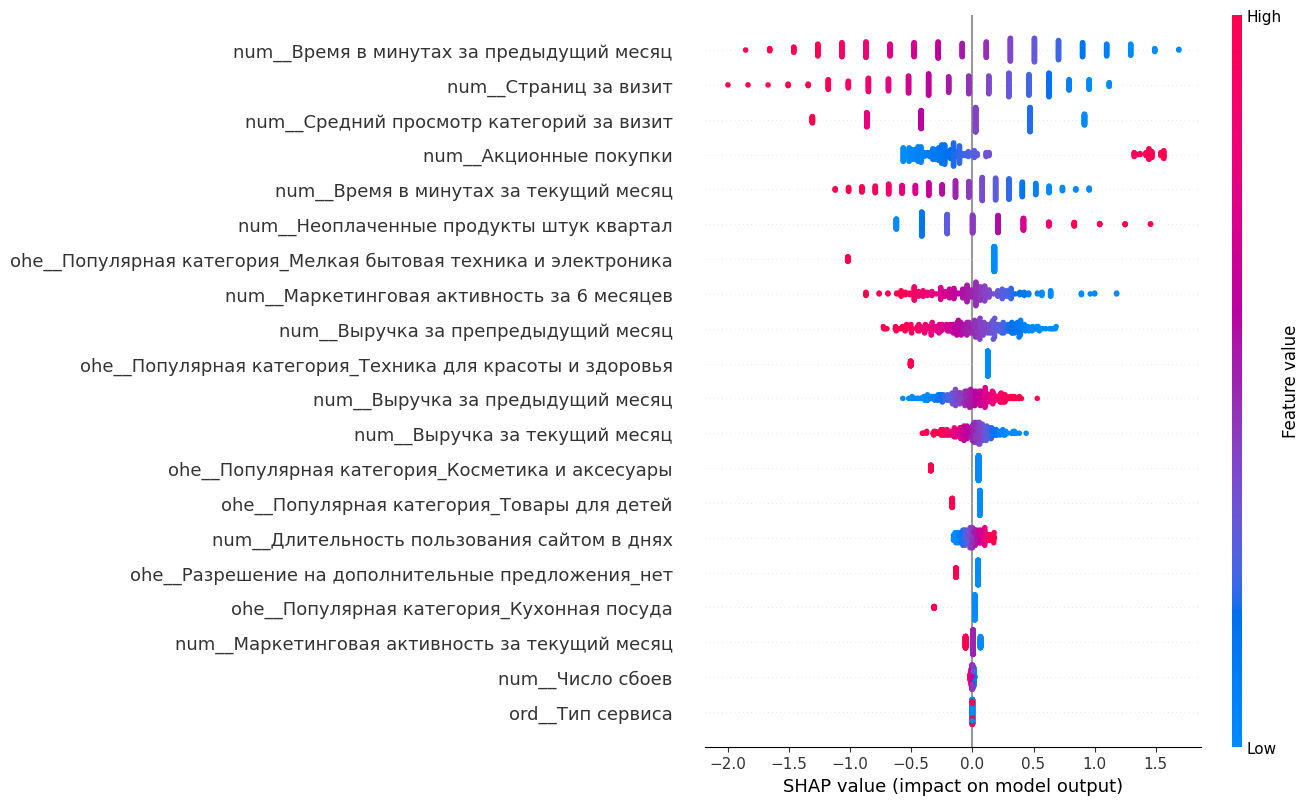

In [97]:
shap.plots.beeswarm(shap_values, max_display=20)

Высокие значения ТОП-3 признаков (Время (на сайте) в минутах за предудущий месяц', 'Страниц за визит', 'Средний просмотр категорий за визит') склоняют модель присвоить класс 0 (Прежний уровень покпательской активности).

С признаком 'Акционные покупки' - ситуация обратная. Высокая доля акционных покупок уверенно склоняет модель присваивать объекту класс 1 (Снижение покупательской активности). При этом умеренные значения доли акционных покупок имеют меньшее влияние на результат работы модели (склоняют её к классу 0, но вклад таких значений не велик).

### shap.plots.waterfall

**Проанализируем влияние признаков на классификацию наблюдения с индексом 25.**

In [98]:
random_search.predict(X_test)[25]

1

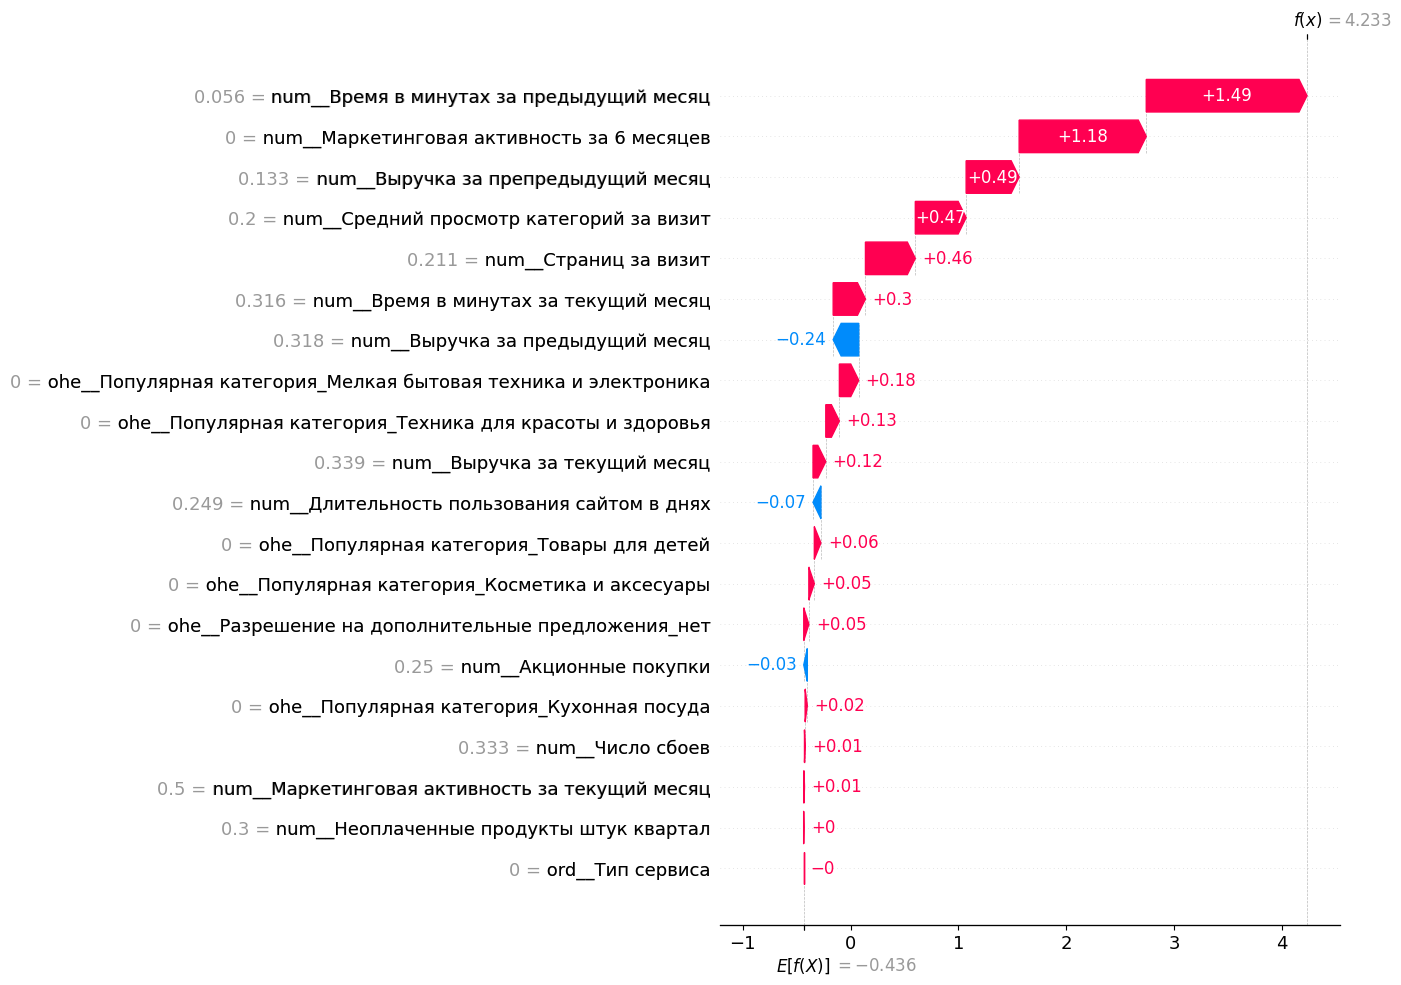

In [99]:
shap.plots.waterfall(shap_values[25], max_display=20) 

**Объект отнесен к классу 1 (Покупательская активность снизилась).**

- Наибольшее влияние на результат классификации наблюдения оказало очень низкое значение признака 'Время (на сайте) в минутах за предудущий месяц'.
- Также велик вклад низкого значения признака 'Маркетинговая активность за 6 месяцев'
- Существенное влияние оказали признаки: 'Выручка за предыдущий месяц', 'Средний просмотр категорий за визит', 'Страниц за визит', 'Время (на сайте) в минутах за текущий месяц', - их значения также низкие.

**Проанализируем влияние признаков на классификацию наблюдения с индексом 14.**

In [100]:
random_search.predict(X_test)[14]

0

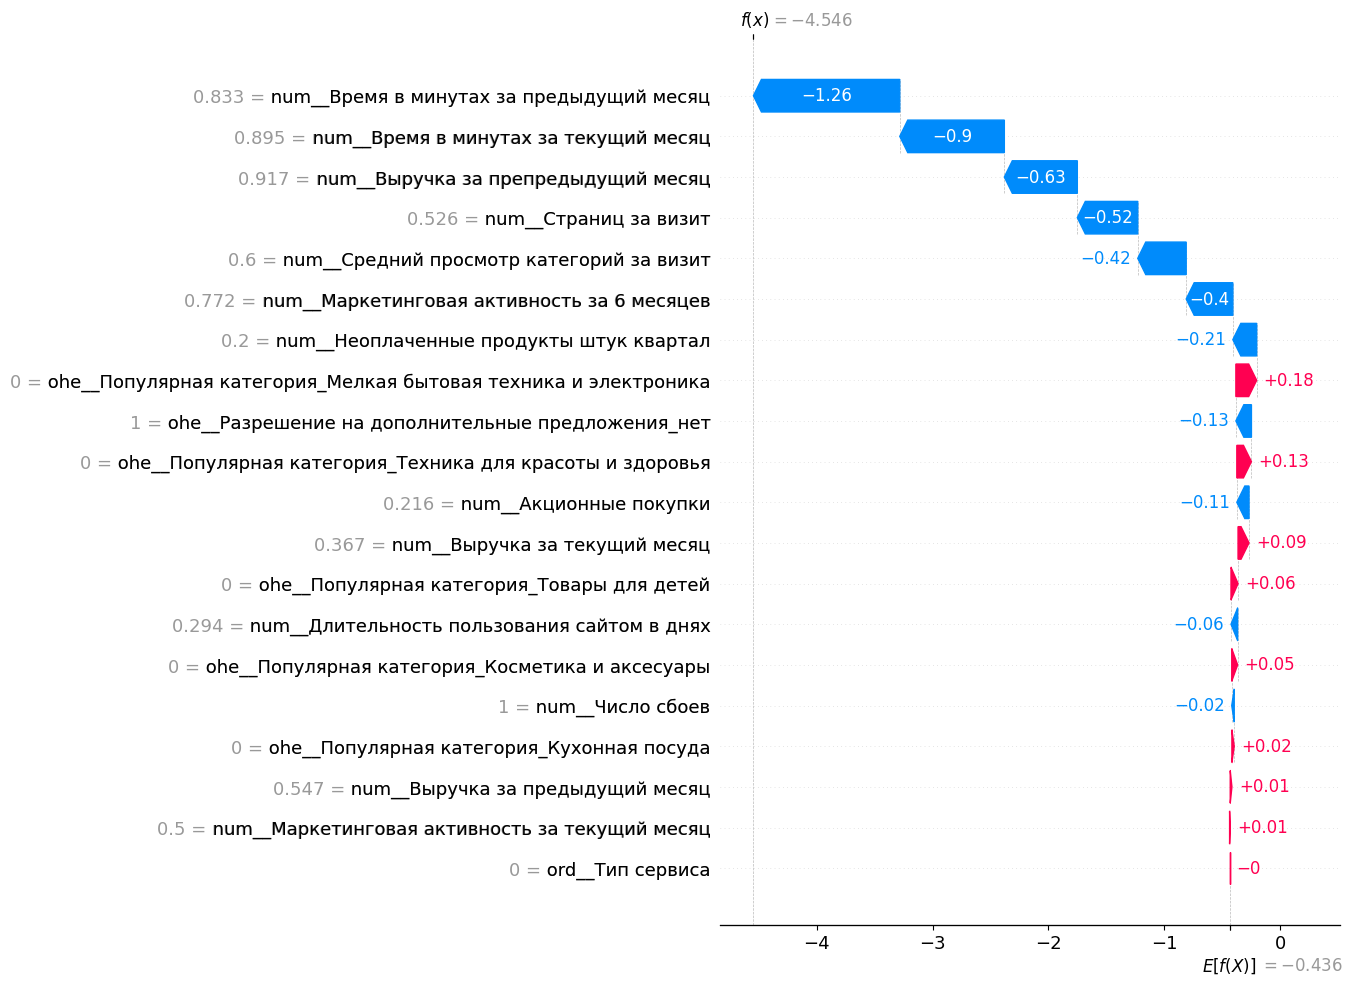

In [101]:
shap.plots.waterfall(shap_values[14], max_display=20) 

**Объект отнесен к классу 0 (Покупательская активность прежнего уровня).**

- Наибольшее влияние на результат классификации наблюдения, как и с объектом 25, оказало высокое значение признака 'Время (на сайте) в минутах за предудущий месяц' - на этои раз высокое.
- Второй по значимости вклад - высокого значения признака 'Время (на сайте) в минутах за текущий месяц'.
- Также существенное влияние оказали признаки: 'Выручка за предыдущий месяц', 'Страниц за визит', 'Средний просмотр категорий за визит', 'Маркетинговая активность за 6 месяцев', - в данном случае значения этих параметров высокие.

### Вывод
Наиболее высокое влияние на классификацию оказывают признаки, связанные со временем проведенным на сайте (в предыдущем и текущем месяце), количеством просматриваемых за визит страниц и категорий, количеством неоплаченных продуктов в корзине, маркетинговой активностью в отношении пользователя, долей акционных покупок. 

Продавец может влиять на перечисленные показатели. Увеличение маркетинговой активности в отношении пользователя может повлечь увеличение времени, проводимого пользователем на сайте, объема просматриваемой информации и, как следствие, способствовать увеличению покупательской активности.

Также стоит обратить внимание, что пользователи, совершающие покупки преимущественно по акциям, склонны к снижению покупательской активности.

## Шаг 8. Сегментация покупателей

Исходные данные содержат информацию о фактах снижения покупательской активности или сохранения её прежнего уровняю Разработанная модель предсказывает вероятность снижения покупательской активности на основе всех признаков пользователя.

Добавим в data столбец с вероятностями снижения покупательской активности, рассчитанными моделью, и данные о прибыли покупателей.

Выделим группу клиентов с высокой вероятностью снижения покупательской активности и высокой прибыльностью. Проанализируем данные с целью поиска способа сохранения покупательской активности высокоприбыльных клиентов.

In [102]:
data['Вероятность снижения покупательской активности'] = random_search.best_estimator_.predict_proba(X)[:, 1]
data = data.merge(money, on='id')

data.sample(3)

,id,Покупательская активность,Тип сервиса,Разрешение на дополнительные предложения,Маркетинговая активность за 6 месяцев,Маркетинговая активность за текущий месяц,Длительность пользования сайтом в днях,Акционные покупки,Популярная категория,Средний просмотр категорий за визит,...,Число сбоев,Страниц за визит,Доля покупок по акции категориальный,Выручка за предыдущий месяц,Выручка за препредыдущий месяц,Выручка за текущий месяц,Время в минутах за предыдущий месяц,Время в минутах за текущий месяц,Вероятность снижения покупательской активности,Прибыль
617,215968,Прежний уровень,стандарт,да,4.9,5,574,0.28,Косметика и аксесуары,4,...,5,5,умеренная,5355.5,4742.0,6017.2,13,19,0.299879,3.04
944,216295,Прежний уровень,стандарт,нет,5.1,3,712,0.33,Мелкая бытовая техника и электроника,2,...,1,10,умеренная,5420.0,5219.0,5724.2,12,9,0.192172,2.68
974,216325,Прежний уровень,стандарт,да,2.6,3,864,0.14,Домашний текстиль,2,...,4,12,умеренная,5299.0,5086.0,5613.6,16,15,0.224287,4.73


**Вероятность снижения покупательской активностии.**

Построим матрицу зависимости количественного признака 'Прибыль' и признака 'Вероятность снижения покупательской активности'. При этом точки на графики выделим разными цветвами с учетом фактического снижения или сохранения покупательской активности.

<function matplotlib.pyplot.show(close=None, block=None)>

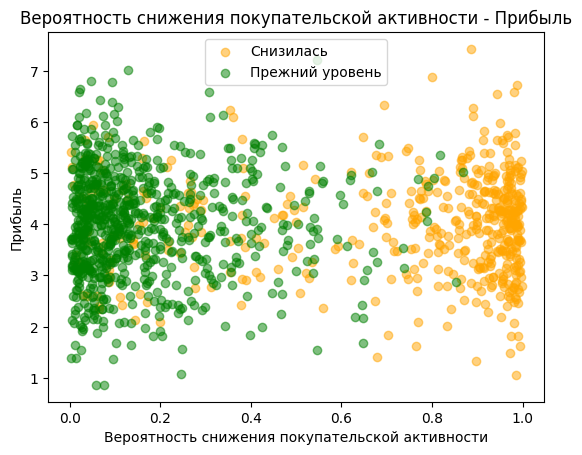

In [103]:
plt.scatter(x=data[data['Покупательская активность'] == 'Снизилась']['Вероятность снижения покупательской активности'], \
            y=data[data['Покупательская активность'] == 'Снизилась']['Прибыль'], label='Снизилась', color='orange', alpha=0.5)
plt.scatter(x=data[data['Покупательская активность'] == 'Прежний уровень']['Вероятность снижения покупательской активности'], \
            y=data[data['Покупательская активность'] == 'Прежний уровень']['Прибыль'], label='Прежний уровень', color='green', alpha=0.5)
plt.title('Вероятность снижения покупательской активности - Прибыль')
plt.xlabel('Вероятность снижения покупательской активности')
plt.ylabel('Прибыль')
plt.legend()
plt.show

1. На интервале вероятности снижения покупательской активности до 0.7 точки разных цветов существенно перемешиваются, плотность точек низкая.

- **Будем считать высокой вероятность снижения покупательской активности от 0.7.**

2. Зависимость между признаками 'Прибыль' и 'Вероятность снижения покупательской активности' не визуализируется.

**Прибыль** 

Среднее значение прибыли и медиана - 4 у.е. Распределение близко к нормальному (пункт 3.15). Стандартное отклонение 1 у.е.

- **Будем считать высокоприбыльными клиентов со среднемесячной прибылью от 4.5 у.е.** (отстощих от среднего значения среднемесячной прибыли на половину СКО).

In [104]:
len(data[data['Прибыль'] >= 4.5])

413

In [105]:
len(data[(data['Прибыль'] >= 4.5) & (data['Вероятность снижения покупательской активности'] >= 0.7)])

116

**В сегмент высокоприбыльных клиентов попали 413 пользователей (32% выборки data)**, в том числе клиентов с высокой вероятностью снижения покупательской активности и высокой прибыльностью попали 115 пользователя (9% от выборки data).

**Анализ важности признаков модели выявил признаки с наибольшим влиянием на Вероятность снижения покупательской активнсти.** Проиллюстрируем зависимости, добавив информацию о прибыльности клиентов.

In [106]:
def probability_chart(column_name):
    plt.scatter(x=data[data['Прибыль'] < 4.5][column_name], \
            y=data[data['Прибыль'] < 4.5]['Вероятность снижения покупательской активности'], label='другие', alpha=0.5)
    plt.scatter(x=data[data['Прибыль'] >= 4.5][column_name], \
            y=data[data['Прибыль'] >= 4.5]['Вероятность снижения покупательской активности'], label='высокоприбыльные', color='red', alpha=0.5)
    plt.title(f'Зависимость вероятности снижения покупательской активности от признака {column_name}.')
    plt.xlabel(column_name)
    plt.ylabel('Вероятность снижения покупательской активности')
    plt.legend()
    plt.show

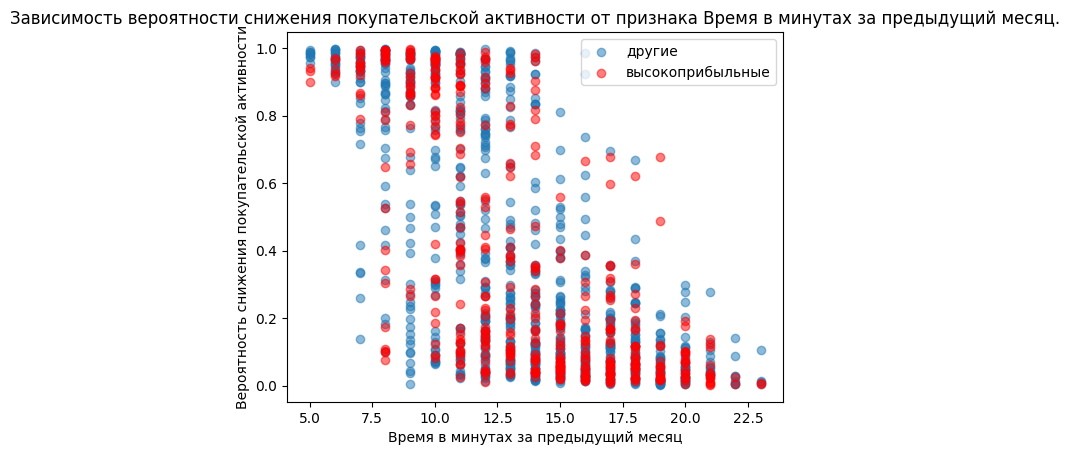

In [107]:
probability_chart('Время в минутах за предыдущий месяц')

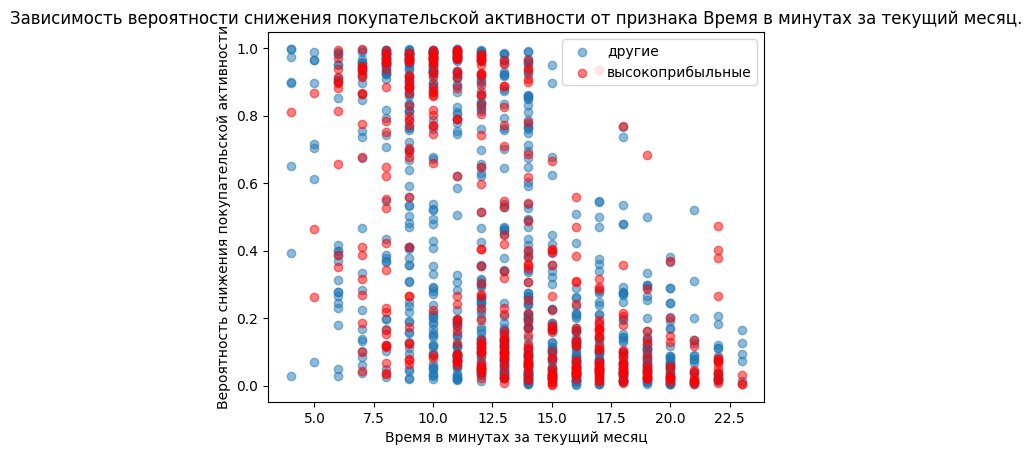

In [108]:
probability_chart('Время в минутах за текущий месяц')

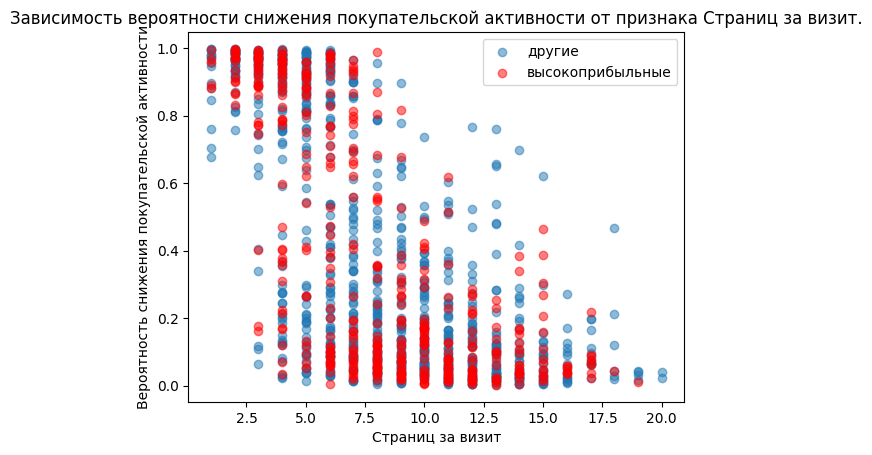

In [109]:
probability_chart('Страниц за визит')

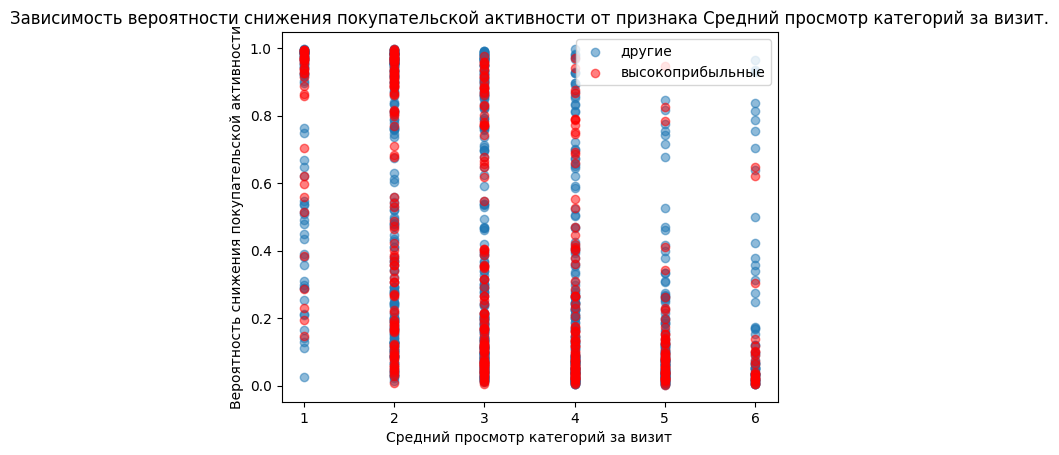

In [110]:
probability_chart('Средний просмотр категорий за визит')

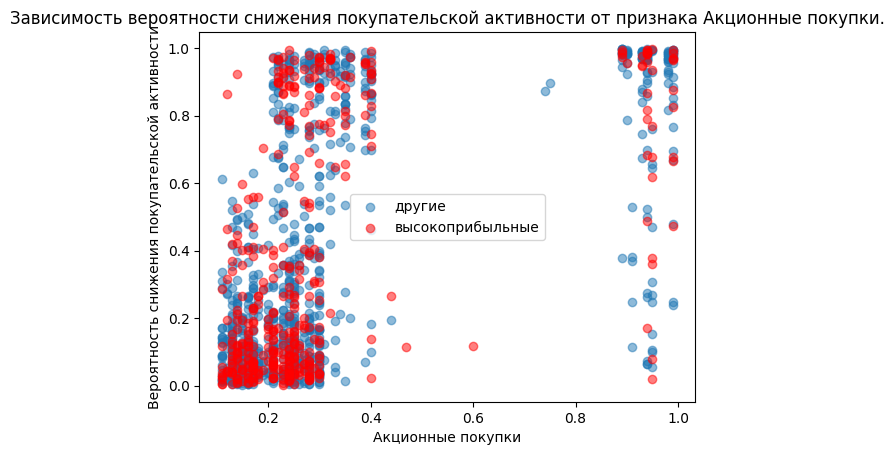

In [111]:
probability_chart('Акционные покупки')

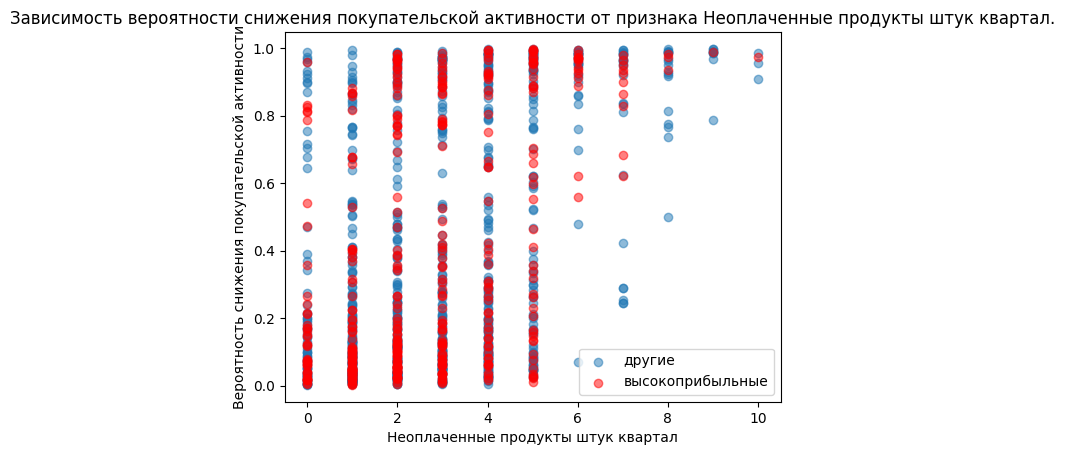

In [112]:
probability_chart('Неоплаченные продукты штук квартал')

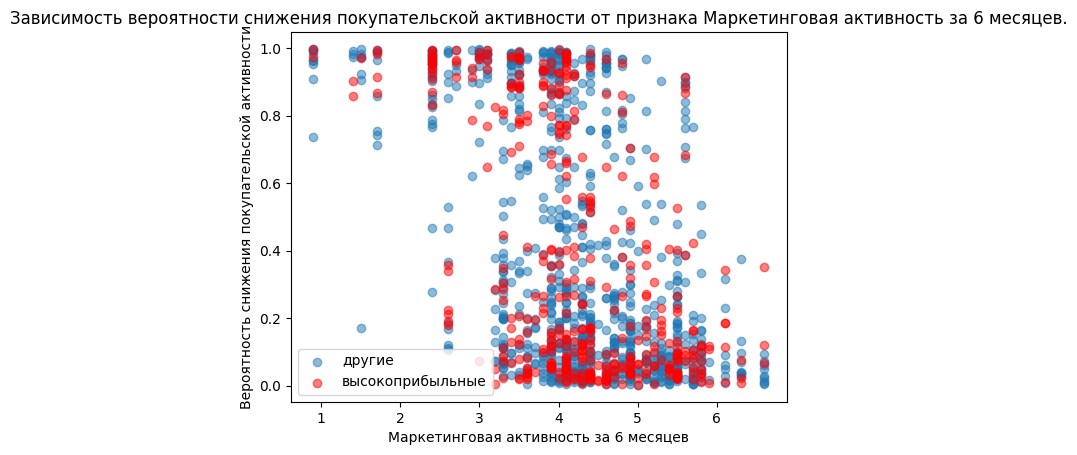

In [113]:
probability_chart('Маркетинговая активность за 6 месяцев')

**Зависимость вероятности снижения покупательской активности от ключевых признаков модели по высокоприбыльным клиентам аналогична зависимости по остальным клиентам.**

**Рекомендации:** Влияние на время проводимое клиентами на сайте, количество просмотриваемых страних и категорий через:

- увеличение маркетинговой активности в отношении клиентов (рассылка предложений исходя из интересов),
- стимуляцию оплаты товаров в корзине.

Посмотрим, **какие категории предпочитают высокоприбыльные клиенты с высокой вероятностью снижения покупательской активности.**

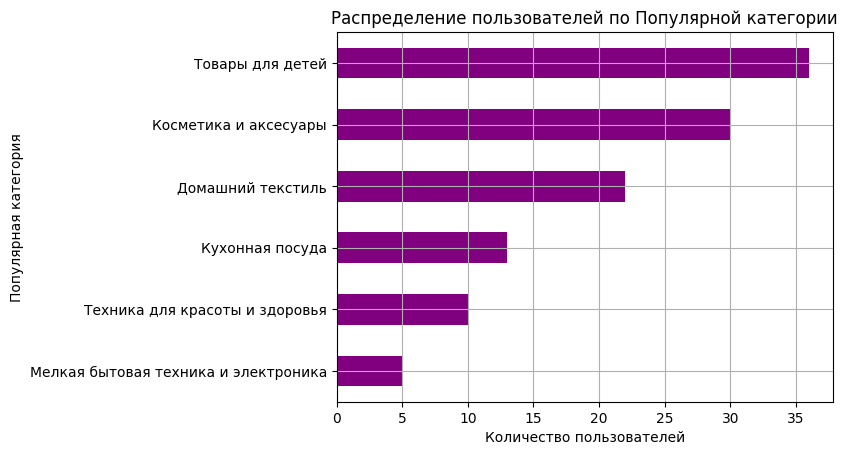

In [114]:
data[(data['Прибыль'] >= 4.5) & (data['Вероятность снижения покупательской активности'] >= 0.7)]\
['Популярная категория'].value_counts().sort_values().plot(kind='barh', grid=True, color='purple')
plt.title('Распределение пользователей по Популярной категории')
plt.xlabel('Количество пользователей')
plt.ylabel('Популярная категория')
plt.show()

1. Для большинства высокоприбыльных клиентов с высокой вероятностью снижения покупательской активности, как и для всех клиентов магазина (пункт 3.6) **наиболее часто встречающейся популярной категорией являются 'Товары для детей'**. 2-3 место - 'Косметика и аксессуары', 'Домашний текстиль' соответственно.

- Магазину стоит создать интересные предложения и акции по популярным категорям.

2. В отличие от всех клиентов выборки, высокоприбыльные клиенты с высокой вероятностью снижения покупательской активности **не так часто покупают в магазине 'Мелкую бытовую технику и электронику', 'Технику для красоты и здоровья'**.

- По непопулярным категорям магазин может расширить продуктовую линейку и так же создать интересные предложения, с целью привлечь клиентов покупать товары данных категорий у себя.